In [ ]:
# tutorials :
# https://github.com/TLutchyn/Molecules-tutorial/blob/main/LOG_meetup_tutorial_GNN_molecules.ipynb
# https://github.com/masashitsubaki/molecularGNN_smiles
# https://dmol.pub/
# https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/06-graph-neural-networks.html
# https://lightning.ai/docs/pytorch/stable/notebooks/course_UvA-DL/06-graph-neural-networks.html

# data :

https://github.com/gauravsdeshmukh/ChemGCN/blob/main/data/solubility_data.csv

In [ ]:
# https://projects.volkamerlab.org/teachopencadd/talktorials/T035_graph_neural_networks.html

In [1]:
print('''

Graph Neural Networks (GNNs) can be applied to several different types of prediction tasks, 
depending on whether the goal is to learn properties of an entire graph, individual nodes, or edges between nodes.

Graph-Level Tasks

Graph-level tasks aim to predict a property of the entire graph.
In molecular applications, the graph represents a molecule, where atoms are nodes and chemical bonds are edges.

Examples include:

Classification tasks — such as predicting whether a molecule is toxic or non-toxic.
Regression tasks — such as predicting molecular properties like solubility, lipophilicity, or binding affinity.

In this tutorial, we focus on a regression task for molecular property prediction.

Another important graph-level application is molecule generation, where the model learns to create entirely new molecular graphs. This is highly relevant in drug discovery, where researchers search for novel therapeutic compounds.

Node-Level Tasks

Node-level tasks focus on predicting properties of individual nodes within the graph.

For molecular graphs, this could include:

Predicting the atomic charge or chemical state of each atom.
Classifying atom types or local chemical environments.

Node-level prediction is also central to molecule generation, where new atoms are sequentially added to an existing molecular structure. In this setting, the model predicts which type of atom should be introduced next.

Edge-Level Tasks

Edge-level tasks involve predicting properties or existence of connections between nodes.

Examples include:

Predicting intramolecular forces or bond characteristics between atoms.
Determining whether a chemical bond should exist between two atoms during molecule generation.

In generative chemistry models, edge prediction helps determine how atoms should connect to form chemically valid molecules.

Beyond chemistry, edge prediction is widely used in biological networks, such as inferring interactions 
in a gene regulatory network or predicting protein–protein interactions.

''')



Graph Neural Networks (GNNs) can be applied to several different types of prediction tasks, 
depending on whether the goal is to learn properties of an entire graph, individual nodes, or edges between nodes.

Graph-Level Tasks

Graph-level tasks aim to predict a property of the entire graph.
In molecular applications, the graph represents a molecule, where atoms are nodes and chemical bonds are edges.

Examples include:

Classification tasks — such as predicting whether a molecule is toxic or non-toxic.
Regression tasks — such as predicting molecular properties like solubility, lipophilicity, or binding affinity.

In this tutorial, we focus on a regression task for molecular property prediction.

Another important graph-level application is molecule generation, where the model learns to create entirely new molecular graphs. This is highly relevant in drug discovery, where researchers search for novel therapeutic compounds.

Node-Level Tasks

Node-level tasks focus on predicting prope

In [3]:
print('''Message Passing :

Instead of MLP layers in standard neural networks, GNNs have message-passing layers, 
where we collect information about the neighboring nodes

''')

Message Passing :

Instead of MLP layers in standard neural networks, GNNs have message-passing layers, 
where we collect information about the neighboring nodes




In [ ]:
print('''


One important property of a Graph Neural Network (GNN) is permutation invariance.
This means that changing the order of nodes in a graph should not change the model’s prediction.

For example, consider an adjacency matrix representation of a graph. Reordering the nodes simply 
swaps rows and columns in the matrix. 

Although the matrix representation changes, the underlying graph structure remains exactly the same. 
A well-designed GNN must therefore produce identical outputs regardless of node ordering.

To achieve this, GNNs use permutation-invariant aggregation functions when combining information from neighboring nodes. 
Common aggregation functions include:

Mean pooling
Sum pooling
Max pooling

Because these operations are independent of node order, 
they ensure that the learned graph representation remains consistent under any permutation of nodes.



Using permutation-invariant aggregation is especially important for graph-level tasks, 
where the model predicts a property of the entire graph, such as molecular solubility, toxicity, or binding affinity.

In this tutorial, we focus on graph-level regression tasks, 
and we will introduce two different GNN architectures designed for this purpose.

''')


In [4]:
print('''

GCN : a Graph Convolutional Network (GCN). 

For GCNs, we sum over all neighbors of node 𝑣, including the node 𝑣 itself and aggregate all information. 

We divide it by the degree to keep the range of different nodes comparable.

One disadvantage of GCNs is, that they use a mean-based aggregation and this function is not injective. 

This means that different graphs can lead to the same graph embedding and the network cannot distinguish between the two graphs anymore.

''')



GCN : a Graph Convolutional Network (GCN). 

For GCNs, we sum over all neighbors of node 𝑣, including the node 𝑣 itself and aggregate all information. 

We divide it by the degree to keep the range of different nodes comparable.

One disadvantage of GCNs is, that they use a mean-based aggregation and this function is not injective. 

This means that different graphs can lead to the same graph embedding and the network cannot distinguish between the two graphs anymore.




In [6]:
print('''

GIN : Graph Isomorphism Network (GIN), 

which has been proposed to overcome the disadvantages of GCNs explained above. 

The aggregation function conatins the parameter 𝜖 decides on the importance of the node 𝑣 compared to its neighbors.

The sum aggregation function is more powerful compared to a mean aggregation (used in the GCN above) 

since we can distinguish between more similar graphs.

Two graphs are isomorphic if the graphs are identical except for node permutations. 

GINs can differentiate between non-isomorphic graphs a lot better than other simple GNNs such as GCN and GraphSage. 

For example, the two graphs in the figure above have different embeddings using GINs, 

since we are using a sum-based aggregation without any scaling or averaging. 

It is proven that GINs are as powerful as the Weisfeiler-Lehman test, a common (but not perfect) isomorphism test for graphs

In graph theory, graph isomorphism means that two graphs are essentially the same structure, even if they look different when drawn.

Two graphs are isomorphic if you can rename the vertices of one graph to make it identical to the other.

Many earlier GNNs (like GCN or GraphSAGE) lose structural information because they aggregate neighbor information 

too weakly (often by averaging).

GIN improves this by using a more expressive aggregation function.

''')



GIN : Graph Isomorphism Network (GIN), 

which has been proposed to overcome the disadvantages of GCNs explained above. 

The aggregation function conatins the parameter 𝜖 decides on the importance of the node 𝑣 compared to its neighbors.

The sum aggregation function is more powerful compared to a mean aggregation (used in the GCN above) 

since we can distinguish between more similar graphs.

Two graphs are isomorphic if the graphs are identical except for node permutations. 

GINs can differentiate between non-isomorphic graphs a lot better than other simple GNNs such as GCN and GraphSage. 

For example, the two graphs in the figure above have different embeddings using GINs, 

since we are using a sum-based aggregation without any scaling or averaging. 

It is proven that GINs are as powerful as the Weisfeiler-Lehman test, a common (but not perfect) isomorphism test for graphs

In graph theory, graph isomorphism means that two graphs are essentially the same structure, even if th

In [ ]:
print('''

Batching¶ 

The batch size indicates how many samples from the training data are fed to the neural network before updating model parameter.

''')

In [ ]:
print('''

Pooling :

Pooling layers help a neural network to reduce dimensionality.

There are different ways for pooling, the most common ones are: mean, max and sum, which are permutation invariant. 
    
Hence, pooling layers are also permutation invariant. 
    
For our GCN, we use a global mean pooling layer and for our GIN we use a global sum pooling layer, 

as it was proposed in the original publications listed in the references above.

''')

In [7]:
print('''

Dropout (Regularization) : 

One common problem in deep learning tasks is overfitting. 
This usually means that the dataset used to train the neural network is too small. 

Applying an overfitted network to a different dataset then leads to a high error in prediction, 
since the model is fit too closely to the training data and does not generalize well enough.

To reduce overfitting, one approach is to use dropout layers, which can lead to a better generalization of the model. 
During training, nodes are randomly dropped. 
The probability of dropping nodes is another hyperparameter to be fixed. 
In each iteration, the nodes in a neural network (and the number of nodes) can therefore differ.

''')



Dropout (Regularization) : 

One common problem in deep learning tasks is overfitting. 
This usually means that the dataset used to train the neural network is too small. 

Applying an overfitted network to a different dataset then leads to a high error in prediction, 
since the model is fit too closely to the training data and does not generalize well enough.

To reduce overfitting, one approach is to use dropout layers, which can lead to a better generalization of the model. 
During training, nodes are randomly dropped. 
The probability of dropping nodes is another hyperparameter to be fixed. 
In each iteration, the nodes in a neural network (and the number of nodes) can therefore differ.




Extracting /home/tanasa/CHEMISTRY_GNN/data/raw/qm9.zip
Processing...
100%|███████████████████████████████████████████████████████████████████████████████| 133885/133885 [01:04<00:00, 2073.52it/s]
Done!


QM9 first example: Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1])

### Training GCN ###


/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The data of the dataset is already cached, so any modifications to `data` will not be reflected when accessing its elements. Clearing the cache now by removing all elements in `dataset._data_list`. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)
/home/tanasa/anaconda3/envs/liana_py310/lib/python3.10/site-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage v

Epoch: 0, Train loss: 0.9153606295585632, Val loss: 0.9642685651779175
Epoch: 2, Train loss: 0.8469364643096924, Val loss: 0.9245448112487793
Epoch: 4, Train loss: 0.819635272026062, Val loss: 0.8989796042442322
Epoch: 6, Train loss: 0.7916140556335449, Val loss: 0.8551376461982727
Epoch: 8, Train loss: 0.7589620351791382, Val loss: 0.8237276077270508

### Training GIN ###
Epoch: 0, Train loss: 0.7397971749305725, Val loss: 0.66193687915802
Epoch: 2, Train loss: 0.5454851388931274, Val loss: 0.5868995785713196
Epoch: 4, Train loss: 0.4984090030193329, Val loss: 0.49693480134010315
Epoch: 6, Train loss: 0.47917070984840393, Val loss: 0.4558812081813812
Epoch: 8, Train loss: 0.43821319937705994, Val loss: 0.42744511365890503


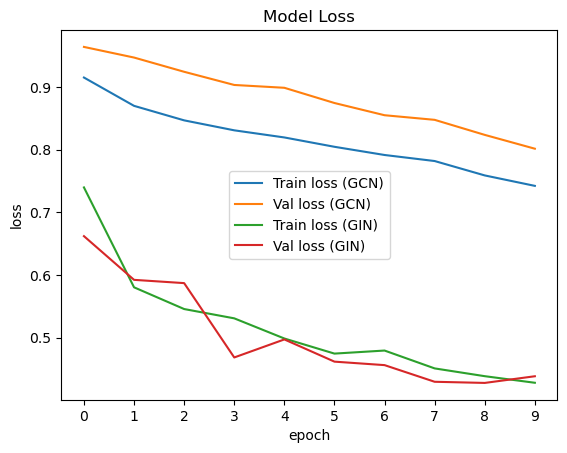

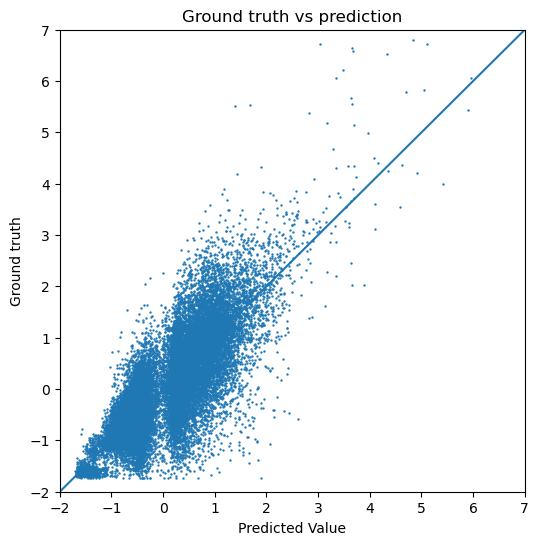


### Evaluating GCN on test set ###


/tmp/ipykernel_235729/1775097878.py:291: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gcn_best.load_state_dict(torch.load("GCN_model.pt"))


Test Loss for GCN: 0.808964192867279


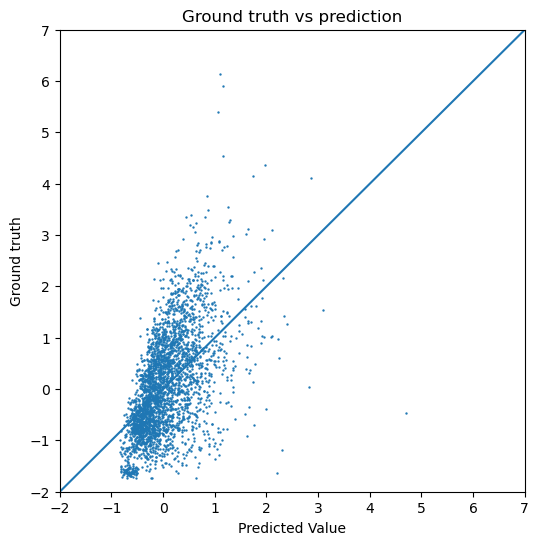


### Evaluating GIN on test set ###


/tmp/ipykernel_235729/1775097878.py:299: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gin_best.load_state_dict(torch.load("GIN_model.pt"))


Test Loss for GIN: 0.47587212920188904


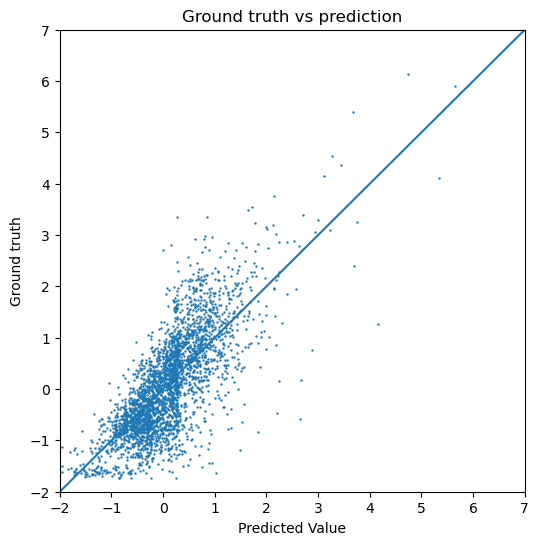

In [8]:
"""
TeachOpenCADD T035 — GNN-based molecular property prediction
============================================================

Local extraction of:
  Paula Linh Kramer (2022),
  "T035 · GNN-based molecular property prediction",
  TeachOpenCADD, Volkamer Lab / NextAID, Saarland University.
  https://projects.volkamerlab.org/teachopencadd/talktorials/T035_graph_neural_networks.html

The tutorial trains and compares two graph neural network architectures
on QM9 (regressing the dipole moment μ):
  - GCN  — Graph Convolutional Network (Kipf & Welling, 2017)
  - GIN  — Graph Isomorphism Network    (Xu et al., 2019)

Both have three message-passing layers + a readout (mean-pool for GCN,
add-pool for GIN) + a small MLP head, with dropout for regularization.

This file is the same code as the notebook, reorganized as a runnable
script and stripped of Colab-specific shell magics.

Requirements:
  pip install torch torch_geometric rdkit
  pip install pandas numpy matplotlib
"""

# ---------------------------------------------------------------------------
# 0. Imports
# ---------------------------------------------------------------------------
import math
from pathlib import Path

import numpy
import pandas as pd
import matplotlib.pylab as plt
from matplotlib.ticker import MaxNLocator

import torch
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU

from torch_geometric.datasets import QM9
from torch_geometric.nn import GCNConv, GINConv
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_add_pool


# ---------------------------------------------------------------------------
# 1. Paths
# ---------------------------------------------------------------------------
HERE = Path(".").resolve()
DATA = HERE / "data"
DATA.mkdir(exist_ok=True)


# ---------------------------------------------------------------------------
# 2. Dataset — QM9
#
# QM9 contains ~130,000 small organic molecules (≤9 heavy atoms) with 19
# different regression targets per molecule. We pick one target (the first
# column = dipole moment μ), z-score-normalize using TRAINING statistics
# only, and split into train / val / test = 80 / 10 / 10 on a sampled
# subset of 30,000 molecules.
# ---------------------------------------------------------------------------
qm9 = QM9(root=str(DATA))
print(f"QM9 first example: {qm9[0]}")
# Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4],
#      y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5])

# Pick one regression target — column 0 (dipole moment μ)
y_target = pd.DataFrame(qm9.data.y.numpy())
qm9.data.y = torch.Tensor(y_target[0])

# Shuffle once so train/val/test contain a representative mix
qm9 = qm9.shuffle()

# 80 / 10 / 10 split on the first 30k molecules
data_size   = 30_000
train_index = int(data_size * 0.8)
test_index  = train_index + int(data_size * 0.1)
val_index   = test_index  + int(data_size * 0.1)

# Z-score normalization using the TRAINING split only
data_mean = qm9.data.y[0:train_index].mean()
data_std  = qm9.data.y[0:train_index].std()
qm9.data.y = (qm9.data.y - data_mean) / data_std

train_loader = DataLoader(qm9[0:train_index],            batch_size=64, shuffle=True)
test_loader  = DataLoader(qm9[train_index:test_index],   batch_size=64, shuffle=True)
val_loader   = DataLoader(qm9[test_index:val_index],     batch_size=64, shuffle=True)


# ---------------------------------------------------------------------------
# 3. Model definitions
# ---------------------------------------------------------------------------
class GCN(torch.nn.Module):
    """Graph Convolutional Network — 3 GCNConv layers + mean-pool + Linear head."""

    def __init__(self, dim_h):
        super().__init__()
        self.conv1 = GCNConv(qm9.num_features, dim_h)
        self.conv2 = GCNConv(dim_h, dim_h)
        self.conv3 = GCNConv(dim_h, dim_h)
        self.lin   = torch.nn.Linear(dim_h, 1)

    def forward(self, data):
        e = data.edge_index
        x = data.x

        x = self.conv1(x, e); x = x.relu()
        x = self.conv2(x, e); x = x.relu()
        x = self.conv3(x, e)

        x = global_mean_pool(x, data.batch)
        x = Fun.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        return x


class GIN(torch.nn.Module):
    """Graph Isomorphism Network — 3 GINConv layers + add-pool + 2-layer MLP head."""

    def __init__(self, dim_h):
        super().__init__()
        self.conv1 = GINConv(
            Sequential(Linear(11, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU())
        )
        self.conv2 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU())
        )
        self.conv3 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU())
        )
        self.lin1 = Linear(dim_h, dim_h)
        self.lin2 = Linear(dim_h, 1)

    def forward(self, data):
        x          = data.x
        edge_index = data.edge_index
        batch      = data.batch

        h = self.conv1(x, edge_index); h = h.relu()
        h = self.conv2(h, edge_index); h = h.relu()
        h = self.conv3(h, edge_index)

        h = global_add_pool(h, batch)

        h = self.lin1(h); h = h.relu()
        h = Fun.dropout(h, p=0.5, training=self.training)
        h = self.lin2(h)
        return h


# ---------------------------------------------------------------------------
# 4. Training / validation / testing utilities
# ---------------------------------------------------------------------------
def training(loader, model, loss, optimizer):
    """Run one training epoch over `loader`."""
    model.train()
    current_loss = 0
    for d in loader:
        optimizer.zero_grad()
        d.x = d.x.float()
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        current_loss += l / len(loader)
        l.backward()
        optimizer.step()
    return current_loss, model


def validation(loader, model, loss):
    """Compute mean validation loss over `loader`."""
    model.eval()
    val_loss = 0
    for d in loader:
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        val_loss += l / len(loader)
    return val_loss


@torch.no_grad()
def testing(loader, model):
    """Compute test loss + return predictions and ground truths."""
    loss = torch.nn.MSELoss()
    test_loss     = 0
    test_target   = numpy.empty((0))
    test_y_target = numpy.empty((0))
    for d in loader:
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        test_loss += l / len(loader)
        test_target   = numpy.concatenate((test_target,   out.detach().numpy()[:, 0]))
        test_y_target = numpy.concatenate((test_y_target, d.y.detach().numpy()))
    return test_loss, test_target, test_y_target


def train_epochs(epochs, model, train_loader, val_loader, path):
    """Train `model` for `epochs` epochs and save the best-validation checkpoint."""
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    loss      = torch.nn.MSELoss()

    train_target   = numpy.empty((0))
    train_y_target = numpy.empty((0))
    train_loss     = numpy.empty(epochs)
    val_loss       = numpy.empty(epochs)
    best_loss      = math.inf

    for epoch in range(epochs):
        epoch_loss, model = training(train_loader, model, loss, optimizer)
        v_loss            = validation(val_loader, model, loss)
        if v_loss < best_loss:
            best_loss = v_loss
            torch.save(model.state_dict(), path)

        # Record true vs predicted on the LAST epoch's training data
        for d in train_loader:
            out = model(d)
            if epoch == epochs - 1:
                train_target   = numpy.concatenate((train_target,   out.detach().numpy()[:, 0]))
                train_y_target = numpy.concatenate((train_y_target, d.y.detach().numpy()))

        train_loss[epoch] = epoch_loss.detach().numpy()
        val_loss[epoch]   = v_loss.detach().numpy()

        if epoch % 2 == 0:
            print(f"Epoch: {epoch}, Train loss: {epoch_loss.item()}, "
                  f"Val loss: {v_loss.item()}")

    return train_loss, val_loss, train_target, train_y_target


# ---------------------------------------------------------------------------
# 5. Plotting helpers
# ---------------------------------------------------------------------------
def plot_loss(gcn_train_loss, gcn_val_loss, gin_train_loss, gin_val_loss):
    plt.plot(gcn_train_loss, label="Train loss (GCN)")
    plt.plot(gcn_val_loss,   label="Val loss (GCN)")
    plt.plot(gin_train_loss, label="Train loss (GIN)")
    plt.plot(gin_val_loss,   label="Val loss (GIN)")
    plt.legend()
    plt.ylabel("loss"); plt.xlabel("epoch")
    plt.title("Model Loss")
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()


def plot_targets(pred, ground_truth):
    f, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(pred, ground_truth, s=0.5)
    plt.xlim(-2, 7); plt.ylim(-2, 7)
    ax.axline((1, 1), slope=1)
    plt.xlabel("Predicted Value"); plt.ylabel("Ground truth")
    plt.title("Ground truth vs prediction")
    plt.show()


# ---------------------------------------------------------------------------
# 6. Run — train GCN and GIN for a few epochs and evaluate
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    EPOCHS = 10   # the tutorial used 100 for the published numbers

    # --- GCN -----------------------------------------------------------
    print("\n### Training GCN ###")
    gcn_model = GCN(dim_h=128)
    gcn_train_loss, gcn_val_loss, gcn_train_target, gcn_train_y_target = train_epochs(
        EPOCHS, gcn_model, train_loader, test_loader, "GCN_model.pt"
    )

    # --- GIN -----------------------------------------------------------
    print("\n### Training GIN ###")
    gin_model = GIN(dim_h=64)
    gin_train_loss, gin_val_loss, gin_train_target, gin_train_y_target = train_epochs(
        EPOCHS, gin_model, train_loader, test_loader, "GIN_model.pt"
    )

    # --- Loss curves --------------------------------------------------
    plot_loss(gcn_train_loss, gcn_val_loss, gin_train_loss, gin_val_loss)

    # --- Training-set parity (GIN) ------------------------------------
    plot_targets(gin_train_target, gin_train_y_target)

    # --- Test-set evaluation: GCN ------------------------------------
    print("\n### Evaluating GCN on test set ###")
    gcn_best = GCN(dim_h=128)
    gcn_best.load_state_dict(torch.load("GCN_model.pt"))
    gcn_test_loss, gcn_test_target, gcn_test_y = testing(test_loader, gcn_best)
    print(f"Test Loss for GCN: {gcn_test_loss.item()}")
    plot_targets(gcn_test_target, gcn_test_y)

    # --- Test-set evaluation: GIN ------------------------------------
    print("\n### Evaluating GIN on test set ###")
    gin_best = GIN(dim_h=64)
    gin_best.load_state_dict(torch.load("GIN_model.pt"))
    gin_test_loss, gin_test_target, gin_test_y = testing(test_loader, gin_best)
    print(f"Test Loss for GIN: {gin_test_loss.item()}")
    plot_targets(gin_test_target, gin_test_y)

In [9]:
print('''

This file (gdb9.sdf.csv) is a molecular property table from the QM9 dataset, 
one of the most widely used benchmark datasets in molecular machine learning and quantum chemistry.

The QM9 dataset contains ~134,000 small organic molecules made of:

Carbon (C)
Hydrogen (H)
Oxygen (O)
Nitrogen (N)
Fluorine (F)

For each molecule, quantum chemistry calculations were performed using Density Functional Theory (DFT), 
and the resulting physical/chemical properties are stored in this CSV file.

Structure of the File

Each row represents one molecule.

Example:

mol_id	molecule
gdb_1	first molecule
gdb_2	second molecule
Explanation of the Columns
Identification
Column	Meaning
mol_id	Unique molecule identifier

Example:

gdb_1
gdb_2
Thermodynamic / Quantum Properties

These columns are numerical targets often used for ML prediction tasks.

Column	Meaning
A, B, C	Rotational constants
mu	Dipole moment
alpha	Isotropic polarizability
homo	HOMO energy
lumo	LUMO energy
gap	HOMO–LUMO energy gap
r2	Electronic spatial extent
zpve	Zero-point vibrational energy
Energy-Related Columns

These correspond to energies computed at different temperatures/conditions.

Column	Meaning
u0	Internal energy at 0 K
u298	Internal energy at 298 K
h298	Enthalpy at 298 K
g298	Free energy at 298 K
cv	Heat capacity
Atomization Energies

These are atomization energies (energy required to separate molecule into atoms).

Column	Meaning
u0_atom	Atomization energy at 0 K
u298_atom	Atomization energy at 298 K
h298_atom	Atomization enthalpy
g298_atom	Atomization free energy
Important Chemistry Concepts
HOMO and LUMO

These are extremely important in chemistry and drug discovery.

HOMO = Highest Occupied Molecular Orbital
LUMO = Lowest Unoccupied Molecular Orbital

The difference:

gap=LUMO−HOMO

is called the band gap or energy gap.

Small gap:

more chemically reactive

Large gap:

more chemically stable
What Is This Dataset Used For?

QM9 is commonly used for:

1. Molecular Property Prediction

Train a GNN or transformer to predict:

dipole moment
solubility proxies
energies
polarizability
HOMO/LUMO
heat capacity

2. Benchmarking GNN Architectures

Popular models tested on QM9:

GCN
GAT
MPNN
SchNet
DimeNet
GemNet
Equivariant Transformers

3. Molecular Representation Learning

Used to learn molecular embeddings for:

drug discovery
materials science
quantum chemistry

''')



This file (gdb9.sdf.csv) is a molecular property table from the QM9 dataset, 
one of the most widely used benchmark datasets in molecular machine learning and quantum chemistry.

The QM9 dataset contains ~134,000 small organic molecules made of:

Carbon (C)
Hydrogen (H)
Oxygen (O)
Nitrogen (N)
Fluorine (F)

For each molecule, quantum chemistry calculations were performed using Density Functional Theory (DFT), 
and the resulting physical/chemical properties are stored in this CSV file.

Structure of the File

Each row represents one molecule.

Example:

mol_id	molecule
gdb_1	first molecule
gdb_2	second molecule
Explanation of the Columns
Identification
Column	Meaning
mol_id	Unique molecule identifier

Example:

gdb_1
gdb_2
Thermodynamic / Quantum Properties

These columns are numerical targets often used for ML prediction tasks.

Column	Meaning
A, B, C	Rotational constants
mu	Dipole moment
alpha	Isotropic polarizability
homo	HOMO energy
lumo	LUMO energy
gap	HOMO–LUMO energy gap
r2	Ele

In [10]:
print("""

TeachOpenCADD T035 — GNN-based molecular property prediction
============================================================
 
Local extraction of:
  Paula Linh Kramer (2022),
  "T035 · GNN-based molecular property prediction",
  TeachOpenCADD, Volkamer Lab / NextAID, Saarland University.
  https://projects.volkamerlab.org/teachopencadd/talktorials/T035_graph_neural_networks.html
 
The tutorial trains and compares two graph neural network architectures
on QM9 (regressing the dipole moment μ):
  - GCN  — Graph Convolutional Network (Kipf & Welling, 2017)
  - GIN  — Graph Isomorphism Network    (Xu et al., 2019)
 
Both have three message-passing layers + a readout (mean-pool for GCN,
add-pool for GIN) + a small MLP head, with dropout for regularization.
 
This file is the same code as the notebook, reorganized as a runnable
script and stripped of Colab-specific shell magics.
 
Requirements:
  pip install torch torch_geometric rdkit
  pip install pandas numpy matplotlib
"""
)



TeachOpenCADD T035 — GNN-based molecular property prediction
 
Local extraction of:
  Paula Linh Kramer (2022),
  "T035 · GNN-based molecular property prediction",
  TeachOpenCADD, Volkamer Lab / NextAID, Saarland University.
  https://projects.volkamerlab.org/teachopencadd/talktorials/T035_graph_neural_networks.html
 
The tutorial trains and compares two graph neural network architectures
on QM9 (regressing the dipole moment μ):
  - GCN  — Graph Convolutional Network (Kipf & Welling, 2017)
  - GIN  — Graph Isomorphism Network    (Xu et al., 2019)
 
Both have three message-passing layers + a readout (mean-pool for GCN,
add-pool for GIN) + a small MLP head, with dropout for regularization.
 
This file is the same code as the notebook, reorganized as a runnable
script and stripped of Colab-specific shell magics.
 
Requirements:
  pip install torch torch_geometric rdkit
  pip install pandas numpy matplotlib



In [11]:
# ---------------------------------------------------------------------------
# 0. Imports
# ---------------------------------------------------------------------------
import math
from pathlib import Path
 
import numpy
import pandas as pd
import matplotlib.pylab as plt
from matplotlib.ticker import MaxNLocator
 
import torch
import torch.nn.functional as Fun
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU
 
from torch_geometric.datasets import QM9
from torch_geometric.nn import GCNConv, GINConv
from torch_geometric.loader import DataLoader
from torch_geometric.nn import global_mean_pool, global_add_pool
 
 
# ---------------------------------------------------------------------------
# 1. Paths
# ---------------------------------------------------------------------------
HERE = Path(".").resolve()
DATA = HERE / "data"
DATA.mkdir(exist_ok=True)

In [12]:
# ---------------------------------------------------------------------------
# 2. Dataset — QM9
#
# QM9 contains ~130,000 small organic molecules (≤9 heavy atoms) with 19
# different regression targets per molecule. We pick one target (the first
# column = dipole moment μ), z-score-normalize using TRAINING statistics
# only, and split into train / val / test = 80 / 10 / 10 on a sampled
# subset of 30,000 molecules.
# ---------------------------------------------------------------------------
qm9 = QM9(root=str(DATA))
print(f"QM9 first example: {qm9[0]}")
# Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4],
#      y=[1, 19], pos=[5, 3], idx=[1], name='gdb_1', z=[5])
 
# Pick one regression target — column 0 (dipole moment μ)
y_target = pd.DataFrame(qm9.data.y.numpy())
qm9.data.y = torch.Tensor(y_target[0])
 
# Shuffle once so train/val/test contain a representative mix
qm9 = qm9.shuffle()
 
# 80 / 10 / 10 split on the first 30k molecules
data_size   = 30_000
train_index = int(data_size * 0.8)
test_index  = train_index + int(data_size * 0.1)
val_index   = test_index  + int(data_size * 0.1)
 
# Z-score normalization using the TRAINING split only
data_mean = qm9.data.y[0:train_index].mean()
data_std  = qm9.data.y[0:train_index].std()
qm9.data.y = (qm9.data.y - data_mean) / data_std
 
train_loader = DataLoader(qm9[0:train_index],            batch_size=64, shuffle=True)
test_loader  = DataLoader(qm9[train_index:test_index],   batch_size=64, shuffle=True)
val_loader   = DataLoader(qm9[test_index:val_index],     batch_size=64, shuffle=True)
 
 

QM9 first example: Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1, 19], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1])


In [13]:
# ---------------------------------------------------------------------------
# 3. Model definitions
# ---------------------------------------------------------------------------
class GCN(torch.nn.Module):
    """Graph Convolutional Network — 3 GCNConv layers + mean-pool + Linear head."""
 
    def __init__(self, dim_h):
        super().__init__()
        self.conv1 = GCNConv(qm9.num_features, dim_h)
        self.conv2 = GCNConv(dim_h, dim_h)
        self.conv3 = GCNConv(dim_h, dim_h)
        self.lin   = torch.nn.Linear(dim_h, 1)
 
    def forward(self, data):
        e = data.edge_index
        x = data.x
 
        x = self.conv1(x, e); x = x.relu()
        x = self.conv2(x, e); x = x.relu()
        x = self.conv3(x, e)
 
        x = global_mean_pool(x, data.batch)
        x = Fun.dropout(x, p=0.5, training=self.training)
        x = self.lin(x)
        return x

In [14]:
 
class GIN(torch.nn.Module):
    """Graph Isomorphism Network — 3 GINConv layers + add-pool + 2-layer MLP head."""
 
    def __init__(self, dim_h):
        super().__init__()
        self.conv1 = GINConv(
            Sequential(Linear(11, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU())
        )
        self.conv2 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU())
        )
        self.conv3 = GINConv(
            Sequential(Linear(dim_h, dim_h), BatchNorm1d(dim_h), ReLU(),
                       Linear(dim_h, dim_h), ReLU())
        )
        self.lin1 = Linear(dim_h, dim_h)
        self.lin2 = Linear(dim_h, 1)
 
    def forward(self, data):
        x          = data.x
        edge_index = data.edge_index
        batch      = data.batch
 
        h = self.conv1(x, edge_index); h = h.relu()
        h = self.conv2(h, edge_index); h = h.relu()
        h = self.conv3(h, edge_index)
 
        h = global_add_pool(h, batch)
 
        h = self.lin1(h); h = h.relu()
        h = Fun.dropout(h, p=0.5, training=self.training)
        h = self.lin2(h)
        return h
 

In [15]:
# ---------------------------------------------------------------------------
# 4. Training / validation / testing utilities
# ---------------------------------------------------------------------------
def training(loader, model, loss, optimizer):
    """Run one training epoch over `loader`."""
    model.train()
    current_loss = 0
    for d in loader:
        optimizer.zero_grad()
        d.x = d.x.float()
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        current_loss += l / len(loader)
        l.backward()
        optimizer.step()
    return current_loss, model
 
 
def validation(loader, model, loss):
    """Compute mean validation loss over `loader`."""
    model.eval()
    val_loss = 0
    for d in loader:
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        val_loss += l / len(loader)
    return val_loss

In [16]:
@torch.no_grad()
def testing(loader, model):
    """Compute test loss + return predictions and ground truths."""
    loss = torch.nn.MSELoss()
    test_loss     = 0
    test_target   = numpy.empty((0))
    test_y_target = numpy.empty((0))
    for d in loader:
        out = model(d)
        l = loss(out, torch.reshape(d.y, (len(d.y), 1)))
        test_loss += l / len(loader)
        test_target   = numpy.concatenate((test_target,   out.detach().numpy()[:, 0]))
        test_y_target = numpy.concatenate((test_y_target, d.y.detach().numpy()))
    return test_loss, test_target, test_y_target
 
 
def train_epochs(epochs, model, train_loader, val_loader, path):
    """Train `model` for `epochs` epochs and save the best-validation checkpoint."""
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    loss      = torch.nn.MSELoss()
 
    train_target   = numpy.empty((0))
    train_y_target = numpy.empty((0))
    train_loss     = numpy.empty(epochs)
    val_loss       = numpy.empty(epochs)
    best_loss      = math.inf
 
    for epoch in range(epochs):
        epoch_loss, model = training(train_loader, model, loss, optimizer)
        v_loss            = validation(val_loader, model, loss)
        if v_loss < best_loss:
            best_loss = v_loss
            torch.save(model.state_dict(), path)
 
        # Record true vs predicted on the LAST epoch's training data
        for d in train_loader:
            out = model(d)
            if epoch == epochs - 1:
                train_target   = numpy.concatenate((train_target,   out.detach().numpy()[:, 0]))
                train_y_target = numpy.concatenate((train_y_target, d.y.detach().numpy()))
 
        train_loss[epoch] = epoch_loss.detach().numpy()
        val_loss[epoch]   = v_loss.detach().numpy()
 
        if epoch % 2 == 0:
            print(f"Epoch: {epoch}, Train loss: {epoch_loss.item()}, "
                  f"Val loss: {v_loss.item()}")
 
    return train_loss, val_loss, train_target, train_y_target
 
 


In [17]:
# ---------------------------------------------------------------------------
# 5. Plotting helpers
# ---------------------------------------------------------------------------
def plot_loss(gcn_train_loss, gcn_val_loss, gin_train_loss, gin_val_loss):
    plt.plot(gcn_train_loss, label="Train loss (GCN)")
    plt.plot(gcn_val_loss,   label="Val loss (GCN)")
    plt.plot(gin_train_loss, label="Train loss (GIN)")
    plt.plot(gin_val_loss,   label="Val loss (GIN)")
    plt.legend()
    plt.ylabel("loss"); plt.xlabel("epoch")
    plt.title("Model Loss")
    plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.show()
 
 
def plot_targets(pred, ground_truth):
    f, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(pred, ground_truth, s=0.5)
    plt.xlim(-2, 7); plt.ylim(-2, 7)
    ax.axline((1, 1), slope=1)
    plt.xlabel("Predicted Value"); plt.ylabel("Ground truth")
    plt.title("Ground truth vs prediction")
    plt.show()


### Training GCN ###
Epoch: 0, Train loss: 0.9154901504516602, Val loss: 0.9247183203697205
Epoch: 2, Train loss: 0.8503018021583557, Val loss: 0.8755232691764832
Epoch: 4, Train loss: 0.8233614563941956, Val loss: 0.8501578569412231
Epoch: 6, Train loss: 0.7981802821159363, Val loss: 0.8132372498512268
Epoch: 8, Train loss: 0.7673025131225586, Val loss: 0.7777254581451416

### Training GIN ###
Epoch: 0, Train loss: 0.7177080512046814, Val loss: 0.597970724105835
Epoch: 2, Train loss: 0.5238580107688904, Val loss: 0.5037513375282288
Epoch: 4, Train loss: 0.4811997711658478, Val loss: 0.4873846173286438
Epoch: 6, Train loss: 0.45320528745651245, Val loss: 0.433558851480484
Epoch: 8, Train loss: 0.4454073905944824, Val loss: 0.3822465240955353


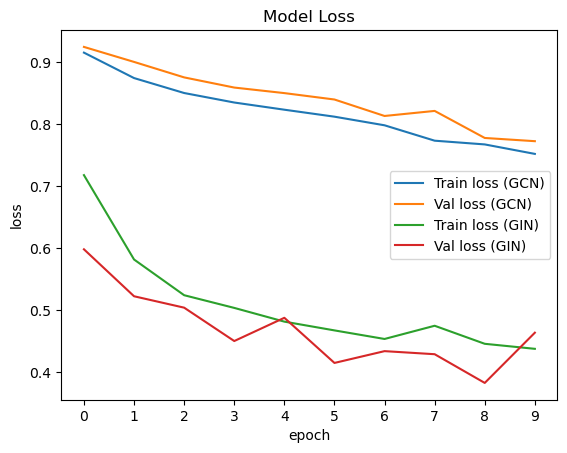

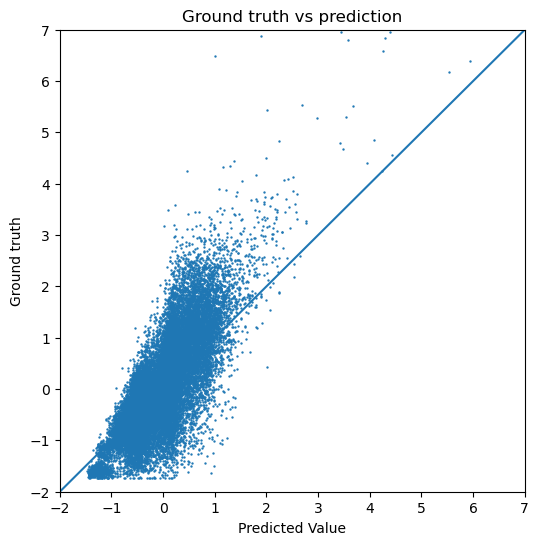


### Evaluating GCN on test set ###


/tmp/ipykernel_235729/965439275.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gcn_best.load_state_dict(torch.load("GCN_model.pt"))


Test Loss for GCN: 0.7761470675468445


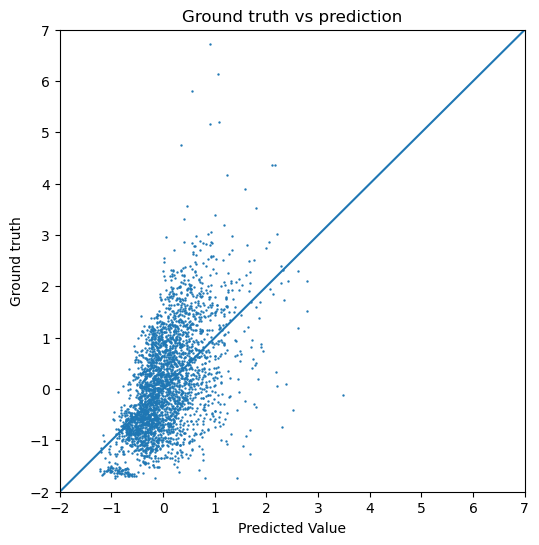


### Evaluating GIN on test set ###


/tmp/ipykernel_235729/965439275.py:38: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gin_best.load_state_dict(torch.load("GIN_model.pt"))


Test Loss for GIN: 0.4436759352684021


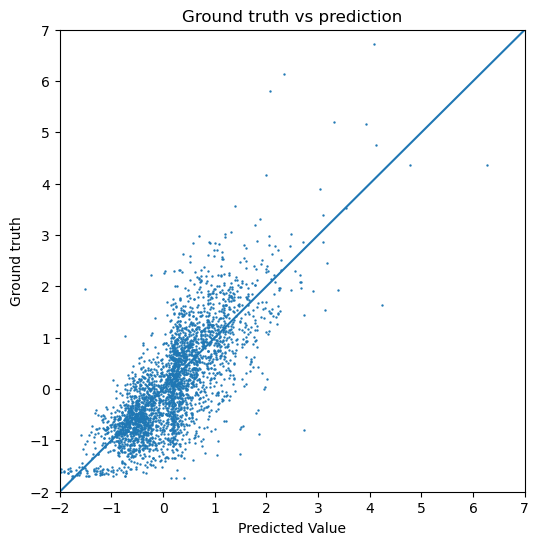

In [18]:
# ---------------------------------------------------------------------------
# 6. Run — train GCN and GIN for a few epochs and evaluate
# ---------------------------------------------------------------------------
if __name__ == "__main__":
    EPOCHS = 10   # the tutorial used 100 for the published numbers
 
    # --- GCN -----------------------------------------------------------
    print("\n### Training GCN ###")
    gcn_model = GCN(dim_h=128)
    gcn_train_loss, gcn_val_loss, gcn_train_target, gcn_train_y_target = train_epochs(
        EPOCHS, gcn_model, train_loader, test_loader, "GCN_model.pt"
    )
 
    # --- GIN -----------------------------------------------------------
    print("\n### Training GIN ###")
    gin_model = GIN(dim_h=64)
    gin_train_loss, gin_val_loss, gin_train_target, gin_train_y_target = train_epochs(
        EPOCHS, gin_model, train_loader, test_loader, "GIN_model.pt"
    )
 
    # --- Loss curves --------------------------------------------------
    plot_loss(gcn_train_loss, gcn_val_loss, gin_train_loss, gin_val_loss)
 
    # --- Training-set parity (GIN) ------------------------------------
    plot_targets(gin_train_target, gin_train_y_target)
 
    # --- Test-set evaluation: GCN ------------------------------------
    print("\n### Evaluating GCN on test set ###")
    gcn_best = GCN(dim_h=128)
    gcn_best.load_state_dict(torch.load("GCN_model.pt"))
    gcn_test_loss, gcn_test_target, gcn_test_y = testing(test_loader, gcn_best)
    print(f"Test Loss for GCN: {gcn_test_loss.item()}")
    plot_targets(gcn_test_target, gcn_test_y)
 
    # --- Test-set evaluation: GIN ------------------------------------
    print("\n### Evaluating GIN on test set ###")
    gin_best = GIN(dim_h=64)
    gin_best.load_state_dict(torch.load("GIN_model.pt"))
    gin_test_loss, gin_test_target, gin_test_y = testing(test_loader, gin_best)
    print(f"Test Loss for GIN: {gin_test_loss.item()}")
    plot_targets(gin_test_target, gin_test_y)